<a href="https://colab.research.google.com/github/MudasirH-coder/Data-Structure-s/blob/main/Move_Recommendation_system_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as p

In [8]:
df = pd.read_csv('/content/movies_DB.csv', on_bad_lines='skip', engine='python')

In [10]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."


In [11]:
#basic EDA Command

df.head()        # First 5 rows
df.tail()        # Last 5 rows
df.shape         # Rows & columns
df.columns       # Column names
df.info()        # Data types + null values
df.describe()    # Statistical summary
df.nunique()     # Unique values count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34691 entries, 0 to 34690
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       34691 non-null  int64  
 1   title          34691 non-null  object 
 2   overview       34648 non-null  object 
 3   genres         34691 non-null  object 
 4   keywords       34691 non-null  object 
 5   director       34642 non-null  object 
 6   release_date   34690 non-null  object 
 7   runtime        34691 non-null  int64  
 8   popularity     34691 non-null  float64
 9   poster_url     34424 non-null  object 
 10  budget         34691 non-null  int64  
 11  revenue        34691 non-null  int64  
 12  tagline        22639 non-null  object 
 13  poster_urls    34691 non-null  object 
 14  video_keys     34691 non-null  object 
 15  review_texts   34691 non-null  object 
 16  external_ids   34691 non-null  object 
 17  certification  19463 non-null  object 
 18  cast  

,0
movie_id,34691
title,32404
overview,34594
genres,3872
keywords,26151
director,13236
release_date,15804
runtime,274
popularity,24028
poster_url,34424


In [12]:
#Metadata Cleaning
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [13]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."


In [15]:
#Fixed Data types
df['release_date'] = pd.to_datetime(df['release_date'])

In [16]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."


In [17]:
df.isnull().sum()

,0
movie_id,0
title,0
overview,43
genres,0
keywords,0
director,49
release_date,1
runtime,0
popularity,0
poster_url,267


In [21]:
df = df.dropna()

In [22]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."


In [24]:
#Remove duplicate data from the dataset
df.duplicated().sum()

df = df.drop_duplicates()

In [25]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","['Family', 'Comedy', 'Animation', 'Adventure']","['rescue', 'friendship', 'mission', 'jealousy'...",John Lasseter,1995-11-22,81,18.5540,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,30000000,394436586,The adventure takes off when toys come to life!,['https://image.tmdb.org/t/p/w500/uXDfjJbdP4ij...,"['_hIfuYVgBrY', 'TZOCUtoygtc', 'CxwTLktovTU', ...","[""This movie came out when I was three. Now I'...","{'id': 862, 'imdb_id': 'tt0114709', 'wikidata_...",G,"[{'name': 'Tom Hanks', 'profile_url': 'https:/..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"['Adventure', 'Fantasy', 'Family']","['giant insect', 'board game', 'disappearance'...",Joe Johnston,1995-12-15,104,2.5713,https://image.tmdb.org/t/p/w500/iWV47r6kFneCiA...,65000000,262821940,It's a jungle in here.,['https://image.tmdb.org/t/p/w500/nLXYV4WmYUF4...,"['aPkVamOQzVQ', 'BBu-chLYTJ8', '1xKR759ghEw', ...","[""Throw the dice and take a turn, Jumanji made...","{'id': 8844, 'imdb_id': 'tt0113497', 'wikidata...",PG,"[{'name': 'Robin Williams', 'profile_url': 'ht..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"['Romance', 'Comedy']","['fishing', 'sequel', 'old man', 'best friend'...",Howard Deutch,1995-12-22,101,2.5156,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,25000000,71500000,Still Yelling. Still Fighting. Still Ready for...,['https://image.tmdb.org/t/p/w500/1FSXpj5e8l4K...,['rEnOoWs3FuA'],[],"{'id': 15602, 'imdb_id': 'tt0113228', 'wikidat...",PG-13,"[{'name': 'Walter Matthau', 'profile_url': 'ht..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","['Comedy', 'Drama', 'Romance']","['based on novel or book', 'single mother', 'd...",Forest Whitaker,1995-12-22,127,3.4707,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,16000000,81452156,Friends are the people who let you be yourself...,['https://image.tmdb.org/t/p/w500/afLVNPUxvBZ5...,['j9xml1CxgXI'],[],"{'id': 31357, 'imdb_id': 'tt0114885', 'wikidat...",R,"[{'name': 'Whitney Houston', 'profile_url': 'h..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"['Comedy', 'Family']","['daughter', 'baby', 'parent child relationshi...",Charles Shyer,1995-12-08,106,2.9373,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,0,76594107,Just when his world is back to normal... he's ...,['https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGr...,['yCg8WNQwe0A'],[],"{'id': 11862, 'imdb_id': 'tt0113041', 'wikidat...",PG,"[{'name': 'Steve Martin', 'profile_url': 'http..."


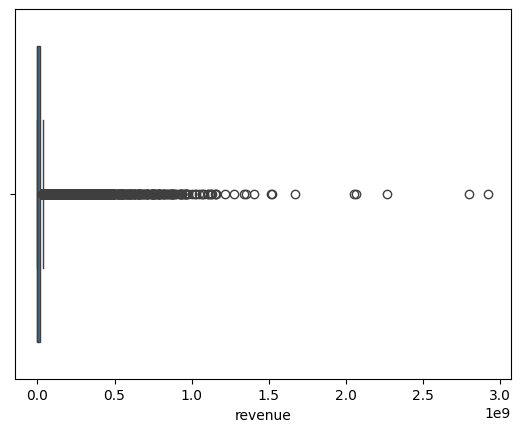

In [27]:
sns.boxplot(x=df['revenue'])
plt.show()

In [33]:
df[df.isnull().any(axis=1)].head(10)

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast


In [36]:
df = df.sample(10)

In [46]:
df["year"] = df["release_date"].dt.year.astype(str)
df = df[df["year"].notnull()]

In [37]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
12248,13784,Black Friday,University professor George Kingsley is struck...,"['Science Fiction', 'Crime', 'Horror', 'Mystery']","['experiment', 'gangster', 'professor', 'murde...",Arthur Lubin,1940-02-29,70,1.7722,https://image.tmdb.org/t/p/w500/268GiPoyYmuNhr...,125750,0,A Reign Of HORROR... a man-made monster on the...,['https://image.tmdb.org/t/p/w500/268GiPoyYmuN...,"['HMYVGdl00Z4', 'aUKx1HeTAJg', 'qjdWyhX4O9I', ...",['Disappointing movie if only because Karloff ...,"{'id': 13784, 'imdb_id': 'tt0032258', 'wikidat...",NR,"[{'name': 'Stanley Ridges', 'profile_url': 'ht..."
3719,16146,Phantasm IV: Oblivion,Taking off immediately where the last one ende...,"['Horror', 'Science Fiction']","['cemetery', 'mausoleum', 'tall man', 'sentina...",Don Coscarelli,1998-07-31,90,0.9155,https://image.tmdb.org/t/p/w500/412lNlGrB8eHBO...,650000,0,You Can't Go Forward Until You've Gone Back.,['https://image.tmdb.org/t/p/w500/8MhaN872Y499...,"['bXZtb7R2rRQ', '9lg7nrOz1es']",[],"{'id': 16146, 'imdb_id': 'tt0138703', 'wikidat...",R,"[{'name': 'Angus Scrimm', 'profile_url': 'http..."
1931,9570,The Black Hole,The explorer craft USS Palomino is returning t...,"['Adventure', 'Science Fiction', 'Action']","['space marine', 'killer robot', 'space travel...",Gary Nelson,1979-12-18,98,1.3745,https://image.tmdb.org/t/p/w500/gCqOJWvOK5UPos...,20000000,35841901,A journey that begins where everything ends!,['https://image.tmdb.org/t/p/w500/gCqOJWvOK5UP...,"['BUH-lN5PRqY', 'GEVP9PHA_20', '0FKJNcV9Ym4', ...","['A little like the ""Godi"" in ""Island at the T...","{'id': 9570, 'imdb_id': 'tt0078869', 'wikidata...",PG,"[{'name': 'Maximilian Schell', 'profile_url': ..."
8903,10485,Ghost Dad,"Elliot Hopper, a widower with three children, ...","['Comedy', 'Family', 'Fantasy']","['daughter', 'parent child relationship', 'los...",Sidney Poitier,1990-06-29,84,0.7581,https://image.tmdb.org/t/p/w500/vYNIUUkJSZixxr...,30000000,25421633,He's been walking through doors. He's been fal...,['https://image.tmdb.org/t/p/w500/vYNIUUkJSZix...,"['wVf-ZAJqJdU', 'Gaj4ALV9IAw']",[],"{'id': 10485, 'imdb_id': 'tt0099654', 'wikidat...",PG,"[{'name': 'Bill Cosby', 'profile_url': 'https:..."
16404,59678,Attack the Block,A teen gang in a South London housing estate m...,"['Action', 'Comedy', 'Science Fiction']","['london, england', 'street gang', 'chase', 'f...",Joe Cornish,2011-05-12,88,2.2865,https://image.tmdb.org/t/p/w500/wzCMnA6NDruLzg...,14350531,3964682,Inner City vs. Outer Space,['https://image.tmdb.org/t/p/w500/wzCMnA6NDruL...,"['ba5uqmptqPk', 'YawsA41VKXo', 'WdHt-Mhzhpc', ...",['It’s raining Gollums!\r\n\r\nAttack the Bloc...,"{'id': 59678, 'imdb_id': 'tt1478964', 'wikidat...",R,"[{'name': 'John Boyega', 'profile_url': 'https..."


In [47]:
df = df[df.duplicated(subset=["title"], keep=False)]

In [49]:
df.head()

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast,year
